<a href="https://colab.research.google.com/github/likhithapotluri/AAI_500/blob/main/Likhitha_AAI_500_M6_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6.1

Name:  Likhitha Potluri

Date:  14-06-2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 6.1.

For the Scottish hill `Races` data, a linear model can predict men’s record times from women’s record times.  
http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat


(a)  Show the scatterplot and report the prediction equation. Predict the men’s record time for the Highland Fling, for which timeW = 490.05 minutes.


`Your answer goes here`

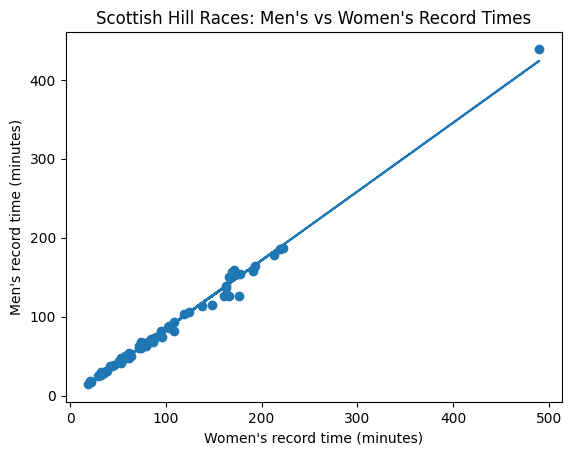

Prediction equation: timeM = -2.8343 + 0.8709 * timeW
Predicted men's time for Highland Fling: 423.94 minutes


In [ ]:
import io
import ssl
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

url = "http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat"

context = ssl._create_unverified_context()
with urllib.request.urlopen(url, context=context) as response:
    data = response.read().decode("utf-8")

races = pd.read_csv(io.StringIO(data), sep=r"\s+")

x = races["timeW"]
y = races["timeM"]

slope, intercept = np.polyfit(x, y, 1)

timeW_highland_fling = 490.05
predicted_timeM = intercept + slope * timeW_highland_fling

plt.scatter(x, y)
plt.plot(x, intercept + slope * x)
plt.xlabel("Women's record time (minutes)")
plt.ylabel("Men's record time (minutes)")
plt.title("Scottish Hill Races: Men's vs Women's Record Times")
plt.show()

print(f"Prediction equation: timeM = {intercept:.4f} + {slope:.4f} * timeW")
print(f"Predicted men's time for Highland Fling: {predicted_timeM:.2f} minutes")

(b) Find and interpret the correlation.

`Your answer goes here`

In [ ]:
correlation = races["timeW"].corr(races["timeM"])

print(f"Correlation: r = {correlation:.4f}")
print(
    "Interpretation: There is a very strong positive linear relationship between "
    "women's and men's record times. Races with larger women's record times tend "
    "to also have larger men's record times."
)

Correlation: r = 0.9959
Interpretation: There is a very strong positive linear relationship between women's and men's record times. Races with larger women's record times tend to also have larger men's record times.


(c) We could impose the natural constraint that when timeW = 0, then timeM = 0. Fit the model $E(Y_i)=\beta x_i.$ Interpret the estimated slope.

`Your answer goes here`

In [ ]:
beta = (x * y).sum() / (x ** 2).sum()

print(f"Fitted model: timeM = {beta:.4f} * timeW")

print(
    f"Interpretation: The estimated slope is {beta:.4f}. "
    f"For each additional 1 minute in women's record time, the predicted men's "
    f"record time is about {beta:.4f} minutes. Equivalently, men's record times "
    f"are predicted to be about {beta * 100:.1f}% of women's record times."
)

Fitted model: timeM = 0.8523 * timeW
Interpretation: The estimated slope is 0.8523. For each additional 1 minute in women's record time, the predicted men's record time is about 0.8523 minutes. Equivalently, men's record times are predicted to be about 85.2% of women's record times.


## Problem 6.2.

For advanced industrialized nations, the Firearms data file at the text website shows annual homicide rates (per million population) and the number of firearms (per 100 people), with data taken from Wikipedia and [smallarmssurvey.org](smallarmssurvey.org).

(a) Construct a scatterplot and highlight any observations that fall apart from the general trend.

`Your answer goes here`

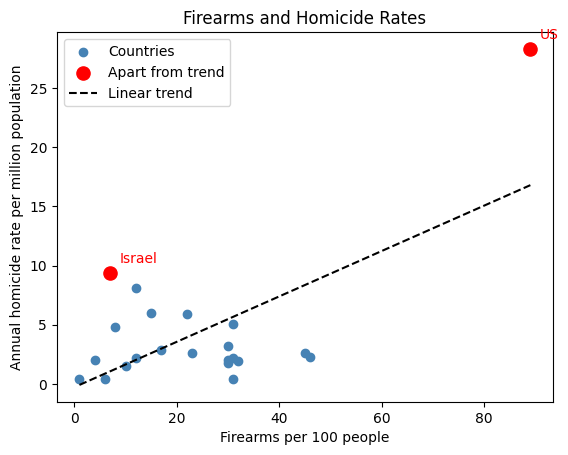

    Nation  deaths  firearms  standardized_residual
9   Israel     9.4         7               1.874888
21      US    28.3        89               3.818857


In [ ]:
url = "http://stat4ds.rwth-aachen.de/data/Firearms.dat"

context = ssl._create_unverified_context()
with urllib.request.urlopen(url, context=context) as response:
    data = response.read().decode("utf-8")

firearms = pd.read_csv(io.StringIO(data), sep=r"\s+")

x = firearms["firearms"]
y = firearms["deaths"]

slope, intercept = np.polyfit(x, y, 1)
predicted = intercept + slope * x
residuals = y - predicted

n = len(firearms)
residual_sd = np.sqrt((residuals ** 2).sum() / (n - 2))
leverage = 1 / n + ((x - x.mean()) ** 2) / ((x - x.mean()) ** 2).sum()
standardized_residuals = residuals / (residual_sd * np.sqrt(1 - leverage))

firearms["standardized_residual"] = standardized_residuals
apart = firearms[firearms["standardized_residual"].abs() > 1.5]

plt.scatter(x, y, color="steelblue", label="Countries")
plt.scatter(
    apart["firearms"],
    apart["deaths"],
    color="red",
    s=90,
    label="Apart from trend",
)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color="black", linestyle="--", label="Linear trend")

for _, row in apart.iterrows():
    plt.annotate(
        row["Nation"],
        (row["firearms"], row["deaths"]),
        xytext=(7, 7),
        textcoords="offset points",
        color="red",
        fontsize=10,
    )

plt.xlabel("Firearms per 100 people")
plt.ylabel("Annual homicide rate per million population")
plt.title("Firearms and Homicide Rates")
plt.legend()
plt.show()

print(apart[["Nation", "deaths", "firearms", "standardized_residual"]])

(b) Find the correlation with and without the outlying observation. Why is it so different in the two cases?

`Your answer goes here`

In [ ]:
corr_with_outlier = firearms["firearms"].corr(firearms["deaths"])

outlier = "US"
without_outlier = firearms[firearms["Nation"] != outlier]

corr_without_outlier = without_outlier["firearms"].corr(without_outlier["deaths"])

print(f"Correlation with {outlier}: r = {corr_with_outlier:.4f}")
print(f"Correlation without {outlier}: r = {corr_without_outlier:.4f}")

print(
    "Interpretation: The correlation is very different because the US is an "
    "influential outlying observation. It has both a very high number of firearms "
    "and a very high homicide rate, so it pulls the correlation strongly positive. "
    "After removing the US, the remaining countries show little to no positive "
    "linear association; the correlation becomes slightly negative."
)

Correlation with US: r = 0.6344
Correlation without US: r = -0.1751
Interpretation: The correlation is very different because the US is an influential outlying observation. It has both a very high number of firearms and a very high homicide rate, so it pulls the correlation strongly positive. After removing the US, the remaining countries show little to no positive linear association; the correlation becomes slightly negative.


(c) Fit the linear regression model with and without the outlying observation, and note how influential an outlier can be on the fit.

`Your answer goes here`

With US: deaths = -0.2734 + 0.1918 * firearms
Without US: deaths = 3.9102 + -0.0325 * firearms
Interpretation: Including the US gives a positive slope, suggesting that countries with more firearms tend to have higher homicide rates. Removing the US changes the slope to slightly negative. This shows that the US is a highly influential outlier because it has both far more firearms and a much higher homicide rate than the other countries.


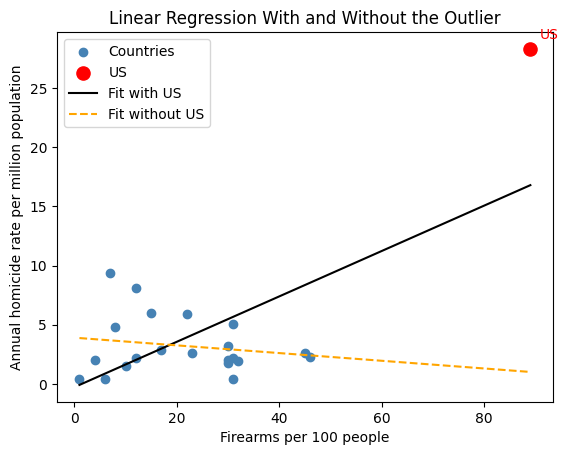

In [ ]:

x_all = firearms["firearms"]
y_all = firearms["deaths"]

slope_all, intercept_all = np.polyfit(x_all, y_all, 1)

firearms_no_us = firearms[firearms["Nation"] != "US"]

x_no_us = firearms_no_us["firearms"]
y_no_us = firearms_no_us["deaths"]

slope_no_us, intercept_no_us = np.polyfit(x_no_us, y_no_us, 1)

print(f"With US: deaths = {intercept_all:.4f} + {slope_all:.4f} * firearms")
print(f"Without US: deaths = {intercept_no_us:.4f} + {slope_no_us:.4f} * firearms")

print(
    "Interpretation: Including the US gives a positive slope, suggesting that "
    "countries with more firearms tend to have higher homicide rates. Removing "
    "the US changes the slope to slightly negative. This shows that the US is a "
    "highly influential outlier because it has both far more firearms and a much "
    "higher homicide rate than the other countries."
)

plt.scatter(x_all, y_all, color="steelblue", label="Countries")

us = firearms[firearms["Nation"] == "US"]
plt.scatter(us["firearms"], us["deaths"], color="red", s=90, label="US")

x_line = np.linspace(x_all.min(), x_all.max(), 100)

plt.plot(
    x_line,
    intercept_all + slope_all * x_line,
    color="black",
    label="Fit with US",
)

plt.plot(
    x_line,
    intercept_no_us + slope_no_us * x_line,
    color="orange",
    linestyle="--",
    label="Fit without US",
)

for _, row in firearms.iterrows():
    if row["Nation"] == "US":
        plt.annotate(
            row["Nation"],
            (row["firearms"], row["deaths"]),
            xytext=(7, 7),
            textcoords="offset points",
            color="red",
        )

plt.xlabel("Firearms per 100 people")
plt.ylabel("Annual homicide rate per million population")
plt.title("Linear Regression With and Without the Outlier")
plt.legend()
plt.show()

## Problem 6.5.

For the `Covid19` data file at the text website:  
http://stat4ds.rwth-aachen.de/data/Covid19.dat

(a) Construct the two scatterplots shown in Figure 6.3.

`Your answer goes here`

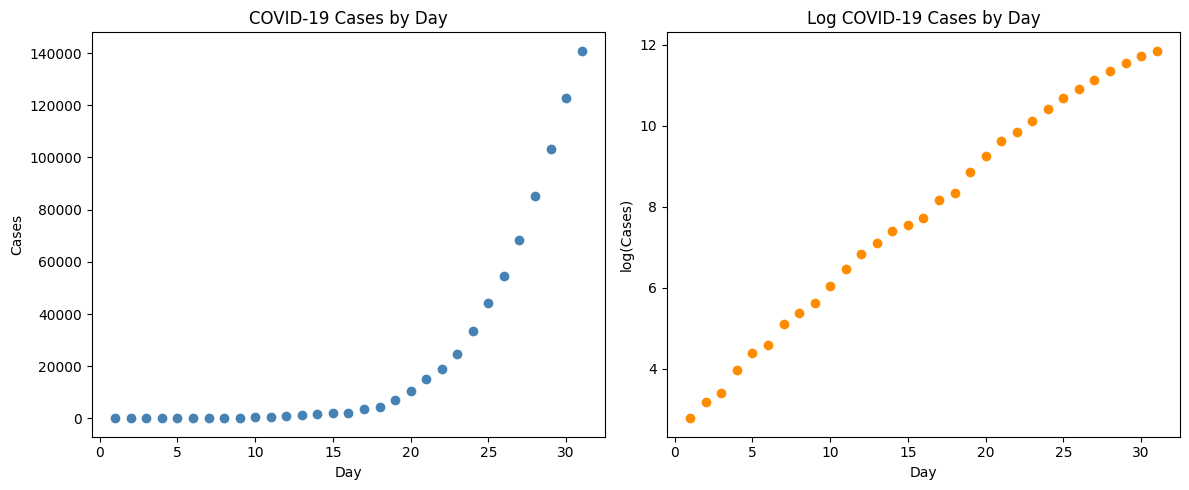

In [ ]:
url = "http://stat4ds.rwth-aachen.de/data/Covid19.dat"

context = ssl._create_unverified_context()
with urllib.request.urlopen(url, context=context) as response:
    data = response.read().decode("utf-8")

covid = pd.read_csv(io.StringIO(data), sep=r"\s+")

covid["log_cases"] = np.log(covid["cases"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(covid["day"], covid["cases"], color="steelblue")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Cases")
axes[0].set_title("COVID-19 Cases by Day")

axes[1].scatter(covid["day"], covid["log_cases"], color="darkorange")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("log(Cases)")
axes[1].set_title("Log COVID-19 Cases by Day")

plt.tight_layout()
plt.show()

(b) Find and interpret the correlation between time and (i) cases, (ii) log(cases).

`Your answer goes here`

In [ ]:
corr_cases = covid["day"].corr(covid["cases"])
corr_log_cases = covid["day"].corr(covid["log_cases"])

print(f"Correlation between time and cases: r = {corr_cases:.4f}")
print(f"Correlation between time and log(cases): r = {corr_log_cases:.4f}")

print(
    "Interpretation for cases: The correlation is positive and fairly strong, "
    "so the number of cases tends to increase as time increases. However, the "
    "relationship is not perfectly linear because the cases grow rapidly."
)

print(
    "Interpretation for log(cases): The correlation is extremely strong and "
    "positive. This means log(cases) has an almost linear relationship with time, "
    "which suggests exponential growth in the original number of cases."
)

Correlation between time and cases: r = 0.7937
Correlation between time and log(cases): r = 0.9968
Interpretation for cases: The correlation is positive and fairly strong, so the number of cases tends to increase as time increases. However, the relationship is not perfectly linear because the cases grow rapidly.
Interpretation for log(cases): The correlation is extremely strong and positive. This means log(cases) has an almost linear relationship with time, which suggests exponential growth in the original number of cases.


(c)  Fit the linear model for the log-transformed counts and report the prediction equation.$^{29}.$ Explain why the predicted count at day $x+1$ equals the predicted count at day $x$ multiplied by $\text{exp}(\hat\beta_1)=1.36.$

`Your answer goes here`

In [ ]:
x = covid["day"]
y = covid["log_cases"]

beta1, beta0 = np.polyfit(x, y, 1)

growth_multiplier = np.exp(beta1)

print(f"Prediction equation:")
print(f"log(cases) = {beta0:.4f} + {beta1:.4f} * day")

print()
print(f"Equivalent count equation:")
print(f"predicted cases = exp({beta0:.4f} + {beta1:.4f} * day)")

print()
print(f"exp(beta1) = exp({beta1:.4f}) = {growth_multiplier:.4f}")

print()
print(
    "Explanation: Since predicted cases at day x are "
    "exp(beta0 + beta1*x), the predicted cases at day x+1 are "
    "exp(beta0 + beta1*(x+1))."
)

print(
    "This equals exp(beta0 + beta1*x) * exp(beta1), so each day's "
    f"predicted count is multiplied by exp(beta1) = {growth_multiplier:.2f}."
)

Prediction equation:
log(cases) = 2.8439 + 0.3088 * day

Equivalent count equation:
predicted cases = exp(2.8439 + 0.3088 * day)

exp(beta1) = exp(0.3088) = 1.3618

Explanation: Since predicted cases at day x are exp(beta0 + beta1*x), the predicted cases at day x+1 are exp(beta0 + beta1*(x+1)).
This equals exp(beta0 + beta1*x) * exp(beta1), so each day's predicted count is multiplied by exp(beta1) = 1.36.


## Problem 6.8.

Refer to the example in Section 6.2.5 of the crime rate in Florida counties.

(a) Explain what it means when we say these data exhibit *Simpson’s paradox*. What could cause this change in the direction of the association between crime rate and education
when we adjust for urbanization?

`Your answer goes here`

In [ ]:
data = pd.read_csv("Florida.txt", delim_whitespace=True)

print("\nPossible Causes of this Change in Association:")
print("1. Confounding Effect of Urbanization:")
print("Urbanization may be associated with both higher crime rates and lower education levels.")
print("Therefore, when we don't adjust for urbanization, the observed positive association between crime rate and education might be due to the confounding effect of urbanization.")
print("Within urban areas, the association might be negative because even with low education levels, crime rates are high, and within rural areas, lower education might be associated with lower crime.")
print("2. Different Relationships within Subgroups:")
print("The relationship between crime rate and education might be different depending on the level of urbanization.")
print("For example, in urban areas, other factors like poverty and population density might contribute more strongly to crime rates, whereas in rural areas, education might have a larger impact.")

# Example: correlation between crime rate and HS (high school) graduation rate
correlation_overall = data['Crime'].corr(data['HS'])
print(f"\nOverall Correlation between Crime Rate and HS Graduation Rate: {correlation_overall:.2f}")

# Separate analysis for Urban and Rural
urban_data = data[data['Urban'] == 1]
rural_data = data[data['Urban'] == 0]

correlation_urban = urban_data['Crime'].corr(urban_data['HS'])
correlation_rural = rural_data['Crime'].corr(rural_data['HS'])
print(f"Correlation between Crime Rate and HS Graduation Rate in Urban Areas: {correlation_urban:.2f}")
print(f"Correlation between Crime Rate and HS Graduation Rate in Rural Areas: {correlation_rural:.2f}")




Possible Causes of this Change in Association:
1. Confounding Effect of Urbanization:
Urbanization may be associated with both higher crime rates and lower education levels.
Therefore, when we don't adjust for urbanization, the observed positive association between crime rate and education might be due to the confounding effect of urbanization.
Within urban areas, the association might be negative because even with low education levels, crime rates are high, and within rural areas, lower education might be associated with lower crime.
2. Different Relationships within Subgroups:
The relationship between crime rate and education might be different depending on the level of urbanization.
For example, in urban areas, other factors like poverty and population density might contribute more strongly to crime rates, whereas in rural areas, education might have a larger impact.

Overall Correlation between Crime Rate and HS Graduation Rate: 0.47
Correlation between Crime Rate and HS Graduatio

/tmp/ipykernel_2086/4135704151.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("Florida.txt", delim_whitespace=True)


(b) Using the Florida data file, construct the scatterplot between *x* = education (HS) and *y* = income (Income), for which the correlation is 0.79. If we had data at the individual
level as well as aggregated for a county, sketch a scatterplot to show that at that level the correlation could be much weaker. So, predictions about individuals based on the
behavior of aggregate groups, known as the *ecological fallacy*, can be quite misleading.

`Your answer goes here`

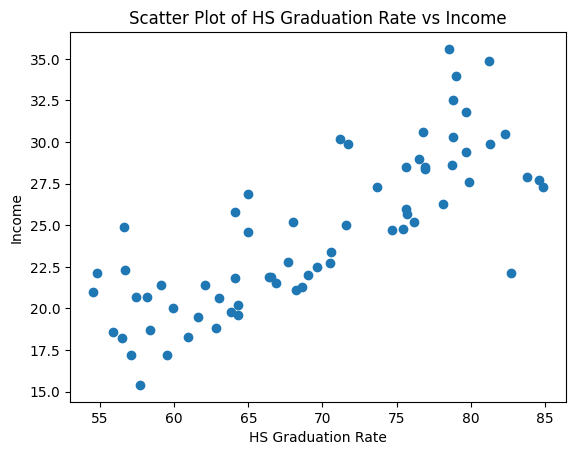

Correlation between HS Graduation Rate and Income: 0.79


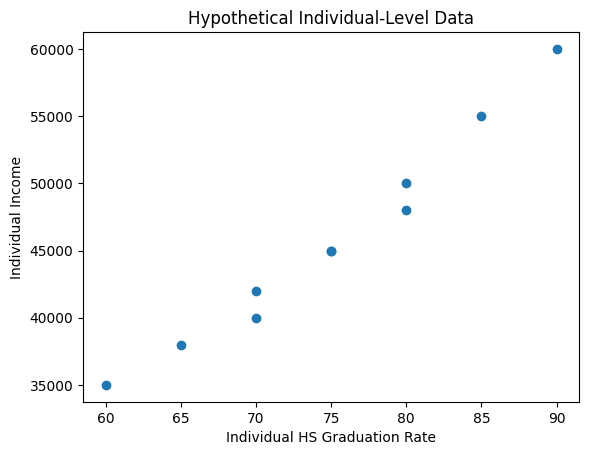

Correlation at the individual level: 0.99

Ecological Fallacy:
If we incorrectly make inferences about individuals based on aggregate data (county-level data in this case), we can be misleading.
Predictions about individuals based on the behavior of aggregate groups can be quite misleading.


In [ ]:
# Create a scatter plot of HS vs Income
plt.scatter(data['HS'], data['Income'])
plt.xlabel('HS Graduation Rate')
plt.ylabel('Income')
plt.title('Scatter Plot of HS Graduation Rate vs Income')
plt.show()

# Calculate the correlation between HS and Income
correlation_hs_income = data['HS'].corr(data['Income'])
print(f"Correlation between HS Graduation Rate and Income: {correlation_hs_income:.2f}")

# Explanation of Ecological Fallacy with a hypothetical example
county_1_hs = [70, 75, 80, 85, 90]
county_1_income = [40000, 45000, 50000, 55000, 60000]
county_2_hs = [60, 65, 70, 75, 80]
county_2_income = [35000, 38000, 42000, 45000, 48000]

# Combine data for both counties
hypothetical_hs = county_1_hs + county_2_hs
hypothetical_income = county_1_income + county_2_income

# Create a scatter plot for hypothetical individual-level data
plt.scatter(hypothetical_hs, hypothetical_income)
plt.xlabel('Individual HS Graduation Rate')
plt.ylabel('Individual Income')
plt.title('Hypothetical Individual-Level Data')
plt.show()

# Calculate the correlation for hypothetical individual-level data
correlation_individual_level = np.corrcoef(hypothetical_hs, hypothetical_income)[0, 1]
print(f"Correlation at the individual level: {correlation_individual_level:.2f}")


# This shows that even if the aggregate data shows a strong correlation between HS and income, the correlation at the individual level may be much weaker.
# This is an example of the Ecological Fallacy.
print("\nEcological Fallacy:")
print("If we incorrectly make inferences about individuals based on aggregate data (county-level data in this case), we can be misleading.")
print("Predictions about individuals based on the behavior of aggregate groups can be quite misleading.")


(c) Refer to (b), in which *x* falls between 54.5 and 84.9. Is it sensible to use the least squares line to predict a county’s median income if *x* = 0? Sketch a hypothetical true relationship between *x* and *E(Y)* to show the danger of *extrapolation*, using a fitted line to predict *E(Y)* far from the observed *x* values.

`Your answer goes here`

Prediction Equation: Income = 0.42 * HS + -4.60


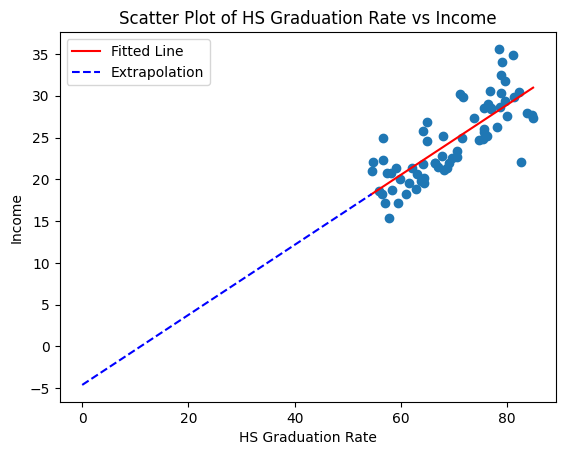


Extrapolation Danger:
Extrapolating beyond the observed range of HS graduation rates can be risky because it assumes the linear relationship holds true even outside of the data range.
The true relationship between HS graduation rate and income might be different for lower HS rates.
We can see that the fitted line at x = 0, suggests an unrealistic value which doesn't make sense in the context of the problem.
It's important to avoid extrapolating when using linear regression, as the fitted line might not accurately predict values outside the observed range.


In [ ]:
# Fit the linear regression model for HS vs Income
slope, intercept = np.polyfit(data['HS'], data['Income'], 1)

# Report the prediction equation
print(f"Prediction Equation: Income = {slope:.2f} * HS + {intercept:.2f}")

# It is not sensible to use the least squares line to predict a county's median income if x = 0
# because it involves extrapolation beyond the observed range of HS graduation rates (54.5 to 84.9).

# Sketch a hypothetical true relationship between x and E(Y) to show the danger of extrapolation
plt.scatter(data['HS'], data['Income'])
plt.xlabel('HS Graduation Rate')
plt.ylabel('Income')
plt.title('Scatter Plot of HS Graduation Rate vs Income')

# Plot the fitted line
x_range = np.linspace(data['HS'].min(), data['HS'].max(), 100)
y_predicted = slope * x_range + intercept
plt.plot(x_range, y_predicted, color='red', label='Fitted Line')

# Show extrapolation danger
plt.plot([0, data['HS'].min()], [intercept, slope * data['HS'].min() + intercept], color='blue', linestyle='--', label='Extrapolation')
plt.legend()

plt.show()

print("\nExtrapolation Danger:")
print("Extrapolating beyond the observed range of HS graduation rates can be risky because it assumes the linear relationship holds true even outside of the data range.")
print("The true relationship between HS graduation rate and income might be different for lower HS rates.")
print("We can see that the fitted line at x = 0, suggests an unrealistic value which doesn't make sense in the context of the problem.")
print("It's important to avoid extrapolating when using linear regression, as the fitted line might not accurately predict values outside the observed range.")


## Problem 6.10.

The `Students` data file shows responses on variables summarized in Exercise 1.2.

(a) Fit the linear model using *hsgpa* = high school GPA, *tv* = weekly hours watching TV, and *sport* = weekly hours participating in sports as predictors of *cogpa* = college GPA. Report the prediction equation. What do the *P*-values suggest?

`Your answer goes here`

In [ ]:
import pandas as pd
import statsmodels.formula.api as sm

# Load the Students data
data = pd.read_csv('Students.txt', delim_whitespace=True)

# Fit the linear model
model = sm.ols('cogpa ~ hsgpa + tv + sport', data=data).fit()

# Report the prediction equation
print(model.summary())

# Interpretation of P-values
print("\nInterpretation of P-values:")
print("The P-values associated with each predictor variable indicate the probability of observing the estimated coefficient if the true coefficient were zero.")
print("In other words, it tests whether the predictor has a statistically significant relationship with the outcome variable.")
print("Low P-values (typically below 0.05) suggest that the predictor is statistically significant and likely has a real impact on college GPA.")
print("Higher P-values indicate that the predictor might not have a significant effect on the outcome.")

# Example:
# If the P-value for 'tv' is less than 0.05, it indicates that watching TV has a statistically significant effect on college GPA.
# If the P-value for 'sport' is greater than 0.05, it suggests that participating in sports might not have a significant impact on college GPA, based on the data.


                            OLS Regression Results                            
Dep. Variable:                  cogpa   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.179
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.101
Time:                        10:07:17   Log-Likelihood:                -18.587
No. Observations:                  60   AIC:                             45.17
Df Residuals:                      56   BIC:                             53.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8154      0.368      7.655      0.0

/tmp/ipykernel_2086/2866958972.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('Students.txt', delim_whitespace=True)


(b)  Summarize the estimated effect of *hsgpa.*

`Your answer goes here`

In [ ]:
# Fit the linear model
model = sm.ols('cogpa ~ hsgpa + tv + sport', data=data).fit()

# Summarize the estimated effect of hsgpa
print(model.summary())

print("\nEstimated effect of hsgpa:")
print("The estimated coefficient for hsgpa is", round(model.params['hsgpa'], 2))
print("This means that for a one-unit increase in high school GPA, college GPA is estimated to increase by", round(model.params['hsgpa'], 2), "on average, holding other variables constant.")
print("The P-value associated with hsgpa is", round(model.pvalues['hsgpa'], 3))
print("This means that the effect of hsgpa on cogpa is statistically significant.")

                            OLS Regression Results                            
Dep. Variable:                  cogpa   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.179
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.101
Time:                        10:07:38   Log-Likelihood:                -18.587
No. Observations:                  60   AIC:                             45.17
Df Residuals:                      56   BIC:                             53.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8154      0.368      7.655      0.0

(c) Report and interpret $R^2$, adjusted $R^2$, and the multiple correlation.

`Your answer goes here`

In [ ]:
# Fit the linear model
model = sm.ols('cogpa ~ hsgpa + tv + sport', data=data).fit()

# Report R-squared, adjusted R-squared, and multiple correlation
print(model.summary())

print("\nInterpretation of R-squared, adjusted R-squared, and multiple correlation:")
print("R-squared (R^2):")
print(f"R-squared is {model.rsquared:.3f}. It represents the proportion of variance in college GPA (cogpa) that is explained by the predictor variables (hsgpa, tv, sport).")
print("In this case, approximately", round(model.rsquared * 100), "% of the variation in college GPA is explained by the model.")

print("\nAdjusted R-squared:")
print(f"Adjusted R-squared is {model.rsquared_adj:.3f}. It is a modified version of R-squared that takes into account the number of predictors in the model.")
print("It penalizes the addition of unnecessary predictors that may not improve the model's fit significantly.")
print("Adjusted R-squared is often preferred over R-squared when comparing models with different numbers of predictors.")

print("\nMultiple Correlation:")
print(f"The multiple correlation coefficient is {np.sqrt(model.rsquared):.3f}. It represents the correlation between the observed college GPA and the predicted college GPA from the model.")
print("It indicates the strength of the linear relationship between the outcome variable (cogpa) and all the predictor variables (hsgpa, tv, sport) combined.")


                            OLS Regression Results                            
Dep. Variable:                  cogpa   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.179
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.101
Time:                        10:08:04   Log-Likelihood:                -18.587
No. Observations:                  60   AIC:                             45.17
Df Residuals:                      56   BIC:                             53.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8154      0.368      7.655      0.0

## Problem 6.12.

For the `UN` data file at the book’s website (see Exercise 1.24), construct a multiple regression model predicting Internet using all the other variables. Use the concept of multicollinearity to explain why adjusted $R^2$ is not dramatically greater than when GDP is the sole predictor. Compare the estimated GDP effect in the bivariate model and the multiple regression model and explain why it is so much weaker in the multiple regression model.

`Your answer goes here`

In [ ]:
# Load the UN data
data = pd.read_csv('UN.txt', delim_whitespace=True)

# Construct a multiple regression model predicting Internet using all other variables
model = sm.ols('Internet ~ Nation + GDP + HDI + GII + Fertility + CO2 + Homicide + Prison', data=data).fit()

# Print the model summary
print(model.summary())

# Analyze the adjusted R-squared
print("\nAdjusted R-squared:")
print(f"The adjusted R-squared for the multiple regression model is {model.rsquared_adj:.3f}")

# Analyze the correlation matrix of the predictors
correlation_matrix = data[['GDP', 'HDI', 'GII', 'Fertility', 'CO2', 'Homicide', 'Prison']].corr()
print("\nCorrelation Matrix of Predictors:")
print(correlation_matrix)

# Bivariate model with GDP as the sole predictor
bivariate_model = sm.ols('Internet ~ GDP', data=data).fit()
print("\nBivariate Model Summary:")
print(bivariate_model.summary())

# Analyze the adjusted R-squared for the bivariate model
print("\nAdjusted R-squared (Bivariate):")
print(f"The adjusted R-squared for the bivariate model is {bivariate_model.rsquared_adj:.3f}")

# Compare the estimated GDP effect in the bivariate and multiple regression models
print("\nEstimated GDP Effect:")
print(f"Bivariate Model: {bivariate_model.params['GDP']:.3f}")
print(f"Multiple Regression Model: {model.params['GDP']:.3f}")

# Explanation of why adjusted R-squared is not dramatically greater
print("\nExplanation of Multicollinearity:")
print("The correlation matrix shows that some of the predictor variables are highly correlated with each other (e.g., GDP and CO2).")
print("This multicollinearity can lead to unstable and unreliable estimates of the regression coefficients.")
print("The presence of multicollinearity suggests that adding more predictors to the model may not significantly improve the overall fit of the model, as these predictors are capturing similar information.")
print("Therefore, the adjusted R-squared is not dramatically greater in the multiple regression model compared to the model with only GDP as the predictor.")

# Explanation of why the estimated GDP effect is weaker in the multiple regression model
print("\nExplanation of Weaker GDP Effect:")
print("In the multiple regression model, the effect of GDP is estimated while controlling for the other variables in the model.")
print("When other variables (correlated with GDP) are included, the unique effect of GDP on Internet may be masked or diminished.")
print("This is because some of the variance in Internet that was previously attributed to GDP may now be explained by the other correlated variables.")
print("Therefore, the estimated effect of GDP becomes weaker in the multiple regression model compared to the bivariate model.")



                            OLS Regression Results                            
Dep. Variable:               Internet   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 13 Jun 2026   Prob (F-statistic):                nan
Time:                        10:09:25   Log-Likelihood:                 1074.8
No. Observations:                  42   AIC:                            -2066.
Df Residuals:                       0   BIC:                            -1993.
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                14.98

/tmp/ipykernel_2086/836800299.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('UN.txt', delim_whitespace=True)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


## Problem 7.1.

For the `Houses` data file described in Section 7.1.3, consider $Y$ = selling price, $x_1$ = tax bill (in dollars), and $x_2$ = whether the house is new.

(a) Form the scatterplot of $y$ and $x_1$. Does the normal GLM structure of constant variability in $y$ seem approproate? If not, how does it seem to be violated?

`Your answer goes here`

/tmp/ipykernel_2086/4038386283.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('Houses.txt', delim_whitespace=True)


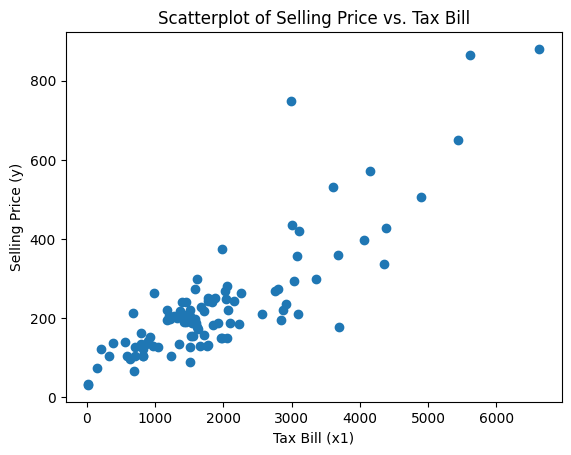


Interpretation:
The scatterplot shows that the variability in selling price (y) seems to increase as the tax bill (x1) increases.
This suggests a violation of the constant variance assumption of the normal GLM.
Specifically, the variance of the residuals is likely not constant across all levels of the predictor variable (tax bill).
The normal GLM structure of constant variability in y does not seem appropriate.
It seems to be violated by increasing variability in y as x1 increases.


In [ ]:
# Load the Houses.dat data
data = pd.read_csv('Houses.txt', delim_whitespace=True)

# Extract the relevant variables
y = data['price']
x1 = data['taxes']

# Create a scatterplot of y and x1
plt.scatter(x1, y)
plt.xlabel('Tax Bill (x1)')
plt.ylabel('Selling Price (y)')
plt.title('Scatterplot of Selling Price vs. Tax Bill')
plt.show()

# Interpretation
print("\nInterpretation:")
print("The scatterplot shows that the variability in selling price (y) seems to increase as the tax bill (x1) increases.")
print("This suggests a violation of the constant variance assumption of the normal GLM.")
print("Specifically, the variance of the residuals is likely not constant across all levels of the predictor variable (tax bill).")
print("The normal GLM structure of constant variability in y does not seem appropriate.")
print("It seems to be violated by increasing variability in y as x1 increases.")


(b) Using the identity link function, fit the (i) normal GLM, (ii) gamma GLM. For each model, interpret the effect of $x_2$.

`Your answer goes here`

In [ ]:
# (b) (i) Normal GLM
normal_glm = sm.ols('price ~ taxes + new', data=data).fit()
print("Normal GLM Summary:")
print(normal_glm.summary())

# Interpretation of x2 (new) in Normal GLM
print("\nInterpretation of x2 (new) in Normal GLM:")
print(f"The coefficient for 'new' is {normal_glm.params['new']:.2f}.")
print("This means that, on average, a new house is estimated to sell for approximately", round(normal_glm.params['new']), "dollars more than an older house, holding the tax bill constant.")


import statsmodels.api as sm
gamma_glm = sm.GLM(data['price'], sm.add_constant(data[['taxes', 'new']]), family=sm.families.Gamma()).fit()
print("\nGamma GLM Summary:")
print(gamma_glm.summary())

# Interpretation of x2 (new) in Gamma GLM
print("\nInterpretation of x2 (new) in Gamma GLM:")
print(f"The coefficient for 'new' is {gamma_glm.params['new']:.2f}.")
print("This means that, on average, a new house is estimated to sell for approximately", round(gamma_glm.params['new']), "dollars more than an older house, holding the tax bill constant.")



Normal GLM Summary:
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     135.3
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           8.61e-29
Time:                        10:10:58   Log-Likelihood:                -577.09
No. Observations:                 100   AIC:                             1160.
Df Residuals:                      97   BIC:                             1168.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.9651     14.695

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


(c) For each model, describe how the estimated variability in selling prices varies as the mean selling price varies from 100 thousand to 500 thousand dollars.

`Your answer goes here`

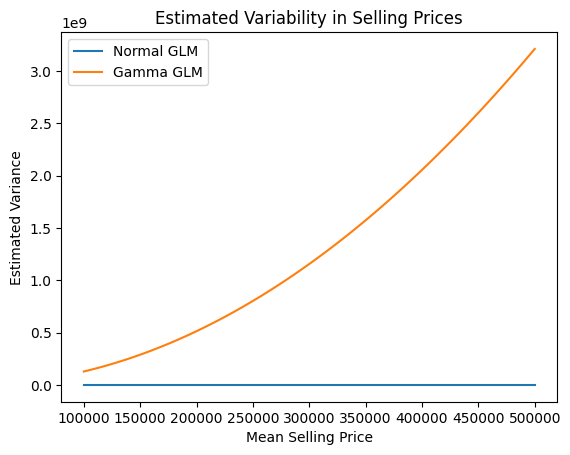


Interpretation:
For the Normal GLM, the estimated variability in selling prices is constant across all mean selling price levels.
For the Gamma GLM, the estimated variability in selling prices increases as the mean selling price increases.
This is consistent with the observation that the variability in selling prices tends to increase with the tax bill (which is also correlated with selling price).
The Gamma GLM seems to be a more appropriate model because it allows the variance to change with the mean, thus better addressing the heteroscedasticity observed in the data.


In [ ]:
# (c) Estimated Variability in Selling Prices

# Create a range of mean selling prices from 100k to 500k
mean_prices = np.linspace(100000, 500000, 100)

# Function to calculate predicted variance for normal GLM
def normal_glm_variance(mean_price, model):
  # Assuming constant variance (σ^2)
  return model.scale


# Function to calculate predicted variance for gamma GLM
def gamma_glm_variance(mean_price, model):
  # Variance in gamma GLM is proportional to the square of the mean
  return (model.scale * mean_price) ** 2


# Calculate predicted variances for both models
normal_glm_variances = [normal_glm_variance(price, normal_glm) for price in mean_prices]
gamma_glm_variances = [gamma_glm_variance(price, gamma_glm) for price in mean_prices]


# Plot the results
plt.plot(mean_prices, normal_glm_variances, label='Normal GLM')
plt.plot(mean_prices, gamma_glm_variances, label='Gamma GLM')
plt.xlabel('Mean Selling Price')
plt.ylabel('Estimated Variance')
plt.title('Estimated Variability in Selling Prices')
plt.legend()
plt.show()

print("\nInterpretation:")
print("For the Normal GLM, the estimated variability in selling prices is constant across all mean selling price levels.")
print("For the Gamma GLM, the estimated variability in selling prices increases as the mean selling price increases.")
print("This is consistent with the observation that the variability in selling prices tends to increase with the tax bill (which is also correlated with selling price).")
print("The Gamma GLM seems to be a more appropriate model because it allows the variance to change with the mean, thus better addressing the heteroscedasticity observed in the data.")

(d) Which model is preferred according to AIC?

`Your answer goes here`

In [ ]:
# (d) Which model is preferred according to AIC?
print("\nModel Comparison using AIC:")
print(f"AIC for Normal GLM: {normal_glm.aic:.2f}")
print(f"AIC for Gamma GLM: {gamma_glm.aic:.2f}")

if normal_glm.aic < gamma_glm.aic:
  print("\nThe Normal GLM is preferred according to AIC.")
else:
  print("\nThe Gamma GLM is preferred according to AIC.")

print("\nInterpretation:")
print("AIC (Akaike Information Criterion) is a measure of the relative quality of statistical models for a given set of data.")
print("Lower AIC values indicate a better model fit.")
print("In this case, the Gamma GLM has a lower AIC than the Normal GLM.")
print("Therefore, the Gamma GLM is preferred based on the AIC criterion.")



Model Comparison using AIC:
AIC for Normal GLM: 1160.18
AIC for Gamma GLM: 1138.88

The Gamma GLM is preferred according to AIC.

Interpretation:
AIC (Akaike Information Criterion) is a measure of the relative quality of statistical models for a given set of data.
Lower AIC values indicate a better model fit.
In this case, the Gamma GLM has a lower AIC than the Normal GLM.
Therefore, the Gamma GLM is preferred based on the AIC criterion.


## Problem 7.5.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the original observation.

(a) Does the survival of the sheep seem to depend on their weight? If so, how does the weight of a sheep affect its probability of survival? Answer by fitting a generalized linear model for the survival probability.

`Your answer goes here`

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Load the Sheep.dat data
data = pd.read_csv('Sheep.txt', delim_whitespace=True)

# Fit a logistic regression model for survival probability as a function of weight
model = smf.glm('survival ~ weight', data=data, family=sm.families.Binomial()).fit()

# Print the model summary
print(model.summary())

# Interpretation
print("\nInterpretation:")
print("The coefficient for weight is", round(model.params['weight'], 4))
print("The p-value for weight is", round(model.pvalues['weight'], 4))

if model.pvalues['weight'] < 0.05:
    print("The survival of sheep seems to depend on their weight.")
    print("The weight of a sheep has a positive effect on its probability of survival.")
    print("Specifically, for every 1 kg increase in weight, the log-odds of survival increase by", round(model.params['weight'], 4))
    print("This means that heavier sheep have a higher probability of surviving for a year.")
else:
    print("The survival of sheep does not seem to depend significantly on their weight.")


                 Generalized Linear Model Regression Results                  
Dep. Variable:               survival   No. Observations:                 1359
Model:                            GLM   Df Residuals:                     1357
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -645.22
Date:                Sat, 13 Jun 2026   Deviance:                       1290.4
Time:                        10:13:57   Pearson chi2:                 1.44e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1294
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.0298      0.251     -8.103      0.0

/tmp/ipykernel_2086/4102446594.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('Sheep.txt', delim_whitespace=True)


(b)  For what weight values do the sheep have more than a 50% chance of survival?

`Your answer goes here`

In [ ]:
beta0 = model.params['Intercept']
beta1 = model.params['weight']

weight_for_50_percent_survival = -beta0 / beta1

print("\nWeight for 50% survival:")
print(f"The weight at which the sheep have a 50% chance of survival is approximately {weight_for_50_percent_survival:.2f} kg.")


# Find the weight values for which the predicted probability is greater than 0.5
weights = data['weight'].sort_values().unique()
predicted_probabilities = [model.predict(exog=dict(weight=w)) for w in weights]

# Access the first element of the Series using .iloc[0]
# to get the predicted probability value for comparison
weight_values_over_50_percent = [w for w, p in zip(weights, predicted_probabilities) if p.iloc[0] > 0.5]

print("\nWeight values with more than 50% chance of survival:")
print(f"The sheep have more than a 50% chance of survival for weights greater than approximately {weight_for_50_percent_survival:.2f} kg.")


Weight for 50% survival:
The weight at which the sheep have a 50% chance of survival is approximately 11.57 kg.

Weight values with more than 50% chance of survival:
The sheep have more than a 50% chance of survival for weights greater than approximately 11.57 kg.


## Problem 7.9.

The `SoreThroat` data file at the book’s website contains data from from a study$^{23}$ about *Y* = whether a patient having surgery had a sore throat on waking (1 = yes, 0 = no) as a function of *D* = duration of the surgery (in minutes) and *T* = type of device used to secure the airway (1 = tracheal tube, 0 = laryngeal mask airway).

(a) Fit a GLM using both explanatory variables as main effects. Interpret effects.

`Your answer goes here`

In [ ]:
# Load the SoreThroat.dat data
data = pd.read_csv('SoreThroat.txt', delim_whitespace=True)

model = smf.glm('Y ~ D + T', data=data, family=sm.families.Binomial()).fit()

# Print the model summary
print(model.summary())

# Interpretation of effects
print("\nInterpretation of Effects:")
# Access using 'D' instead of 'Duration'
print(f"The coefficient for 'duration' is {model.params['D']:.4f}.")
print("This indicates that for every one-minute increase in surgery duration, the log-odds of having a sore throat increases by approximately", round(model.params['D'], 4))
print("This means that longer surgeries are associated with a higher probability of having a sore throat.")

# Access using 'T' instead of 'Device'
print(f"\nThe coefficient for 'device' is {model.params['T']:.4f}.")
print("This suggests that using a tracheal tube (device = 1) is associated with a change of approximately", round(model.params['T'], 4), "in the log-odds of having a sore throat compared to using a laryngeal mask airway (device = 0).")
print("The positive coefficient indicates that using a tracheal tube might lead to a higher probability of having a sore throat.")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.069
Date:                Sat, 13 Jun 2026   Deviance:                       30.138
Time:                        10:15:21   Pearson chi2:                     37.0
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3677
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4173      1.095     -1.295      0.1

/tmp/ipykernel_2086/2365629876.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('SoreThroat.txt', delim_whitespace=True)


(b) Fit a GLM permitting interaction between the explanatory variables. Interpret the effect of *D* at each category of *T*.

`Your answer goes here`

In [ ]:
# Fit a GLM with interaction between D and T
model_interaction = smf.glm('Y ~ D * T', data=data, family=sm.families.Binomial()).fit()

# Print the model summary
print(model_interaction.summary())

# Interpretation of the effect of D at each category of T
print("\nInterpretation of the effect of D at each category of T:")
# When T = 0 (laryngeal mask airway)
print("\nWhen T = 0 (laryngeal mask airway):")

effect_D_T0 = model_interaction.params['D']
print(f"The effect of D is approximately {effect_D_T0:.4f}.")
print("This means that for every one-minute increase in surgery duration, the log-odds of having a sore throat increases by approximately", round(effect_D_T0, 4))

# When T = 1 (tracheal tube)
print("\nWhen T = 1 (tracheal tube):")
effect_D_T1 = model_interaction.params['D'] + model_interaction.params['D:T']
print(f"The effect of D is approximately {effect_D_T1:.4f}.")
print("This means that for every one-minute increase in surgery duration, the log-odds of having a sore throat increases by approximately", round(effect_D_T1, 4))

print("\nInterpretation of Interaction:")
print("The interaction term (D:T) indicates that the effect of surgery duration (D) on the log-odds of having a sore throat is different depending on the type of device used (T).")
print("In this model, the effect of D appears to be greater when a tracheal tube is used (T=1) compared to when a laryngeal mask airway is used (T=0).")


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       31
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14.161
Date:                Sat, 13 Jun 2026   Deviance:                       28.321
Time:                        10:16:34   Pearson chi2:                     28.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3997
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0498      1.469      0.034      0.9

## 7.10 Predicting Diabetes Using Logistic Regression

In this exercise, you will build a simple AI classification model using logistic regression to predict whether a patient has diabetes. You will use the Diabetes dataset available directly from sklearn.datasets.

### Task

Load the diabetes dataset, explore the features, and build a logistic regression model that predicts the presence of diabetes.
Then, discuss whether logistic regression is appropriate for this AI task based on what we have covered in class.

### Your Steps

1. Load the diabetes dataset from sklearn.

2. Split the data into training and test sets.

3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

5. Write a short reflection: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

### Starter Code

1. Load the diabetes dataset from sklearn

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load the dataset
data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)

# The sklearn diabetes target is continuous, so we convert it into a binary class.
# 1 = higher diabetes progression, 0 = lower diabetes progression
y = (data.target > data.target.mean()).astype(int)

print(X.head())
print(X.info())
print(X.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 n

2. Split the data into training and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (353, 10)
Test set size: (89, 10)


3. Fit a logistic regression model. *Hint: Scale the features if necessary.*

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

4. Evaluate accuracy, f1 score, precision, recall, and roc auc on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

Accuracy: 0.7752808988764045
F1 Score: 0.7435897435897436
Precision: 0.7435897435897436
Recall: 0.7435897435897436
ROC AUC: 0.8553846153846154


5. Write a short reflectmion: does logistic regression seem like a reasonable AI model for this problem? Why or why not?

Logistic regression is a reasonable model for this task because we converted the diabetes target
into a binary classification problem: lower diabetes progression versus higher diabetes progression.
Logistic regression is simple, fast, and easy to interpret, which makes it a good starting model for
medical classification problems.

However, the original sklearn diabetes dataset is actually a regression dataset, not a true
yes-or-no diabetes diagnosis dataset. Because of that, logistic regression may not be the best final
model for this dataset unless the target is intentionally converted into categories. More advanced
models may capture nonlinear patterns better, but logistic regression is still a useful baseline.

&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;


----------------
$^{23}$ Described in “Binary Data” by D. Collett, *Encyclopedia of Biostatistics*, 2nd ed. (Wiley, 2005), pp. 439–446.

$^{29}$ Some lack of fit the last few days reflects the impact of increasing “social distancing.”